#Question 1: Metropolis Algorithm


In [ ]:
# Import the libraries we need for numerical computing, data visualization, and statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set a seed so our random numbers are always the same for reproducible results
np.random.seed(42)
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 5)

print('Tools loaded! Ready for MCMC learning.')

Tools loaded! Ready for MCMC learning.


In [ ]:
# This function returns how likely a value x is under the distribution
def target_distribution_example1(x):
    # Set the center (mean) of our distribution to 5
    mean = 5.0
    # Set how wide the distribution is (standard deviation) to 1
    std_dev = 1.0
    # Calculate the exponent part of the Gaussian formula
    exponent = -0.5 * ((x - mean) / std_dev) ** 2
    # Return the actual probability density at this point x
    probability = np.exp(exponent)
    return probability

print('Testing the distribution function:')
print(f'f(5) = {target_distribution_example1(5):.4f} (peak at mean)')
print(f'f(4) = {target_distribution_example1(4):.4f} (1 std dev away)')
print(f'f(6) = {target_distribution_example1(6):.4f} (symmetric)')

Testing the distribution function:
f(5) = 1.0000 (peak at mean)
f(4) = 0.6065 (1 std dev away)
f(6) = 0.6065 (symmetric)


In [ ]:
# Implement the Metropolis algorithm to sample from our target distribution
def metropolis_algorithm(target_distribution, starting_point, proposal_std, num_iterations):
    # Keep track of all samples we collect
    chain = []
    # Keep track of which proposals we accept
    acceptances = []
    # Start at the given starting point
    current_value = starting_point

    # Run the algorithm for the specified number of iterations
    for iteration in range(num_iterations):
        # Generate a random perturbation from a normal distribution
        noise = np.random.normal(0, proposal_std)
        # Propose a new value by adding the noise to our current position
        proposed_value = current_value + noise

        # Evaluate the target distribution at the proposed value
        prob_proposed = target_distribution(proposed_value)
        # Evaluate the target distribution at our current value
        prob_current = target_distribution(current_value)
        # Calculate the ratio of how much more likely the proposed value is
        acceptance_ratio = prob_proposed / prob_current
        # Acceptance probability is the minimum of 1 and this ratio
        acceptance_probability = min(1.0, acceptance_ratio)

        # Draw a random number between 0 and 1
        random_number = np.random.uniform(0, 1)
        # If the random number is less than acceptance probability, accept the move
        if random_number < acceptance_probability:
            current_value = proposed_value
            accepted = True
        else:
            # Otherwise, reject and stay where we are
            accepted = False

        # Add the current value to our collection of samples
        chain.append(current_value)
        # Record whether we accepted this proposal
        acceptances.append(accepted)

    # Convert the list to a numpy array for easier manipulation
    chain = np.array(chain)
    acceptances = np.array(acceptances)
    # Calculate what percentage of our proposals we accepted
    acceptance_rate = 100 * np.mean(acceptances)

    return chain, acceptance_rate

print('Metropolis algorithm defined successfully!')

Metropolis algorithm defined successfully!


In [ ]:
starting_point = 0.0
proposal_std = 1.0
num_iterations = 5000

chain, acceptance_rate = metropolis_algorithm(
    target_distribution=target_distribution_example1,
    starting_point=starting_point,
    proposal_std=proposal_std,
    num_iterations=num_iterations
)

print(f'Algorithm ran successfully!')
print(f'Total iterations: {num_iterations}')
print(f'Acceptance rate: {acceptance_rate:.1f}%')

Algorithm ran successfully!
Total iterations: 5000
Acceptance rate: 71.9%


In [ ]:
# Discard the first 20 percent of samples as burn-in to let the chain forget its starting point
burn_in = int(0.2 * num_iterations)
chain_burned = chain[burn_in:]

# Calculate the mean of our clean samples
empirical_mean = np.mean(chain_burned)
# Calculate the standard deviation of our clean samples
empirical_std = np.std(chain_burned)

# What we know are the true values for a Gaussian with mean 5 and std 1
theoretical_mean = 5.0
theoretical_std = 1.0

# Print the results in a nice format
print('='*60)
print('EXAMPLE 1 RESULTS: METROPOLIS SAMPLING')
print('='*60)
print(f'\nEmpirical (from MCMC): mean = {empirical_mean:.4f}, std = {empirical_std:.4f}')
print(f'Theoretical (true dist): mean = {theoretical_mean:.4f}, std = {theoretical_std:.4f}')
print(f'\nDifference in mean: {abs(empirical_mean - theoretical_mean):.4f}')
print(f'Difference in std: {abs(empirical_std - theoretical_std):.4f}')
print(f'\nConclusion: Metropolis successfully sampled from the target distribution!')
print('='*60)

EXAMPLE 1 RESULTS: METROPOLIS SAMPLING

Empirical (from MCMC): mean = 4.9949, std = 1.0302
Theoretical (true dist): mean = 5.0000, std = 1.0000

Difference in mean: 0.0051
Difference in std: 0.0302

Conclusion: Metropolis successfully sampled from the target distribution!


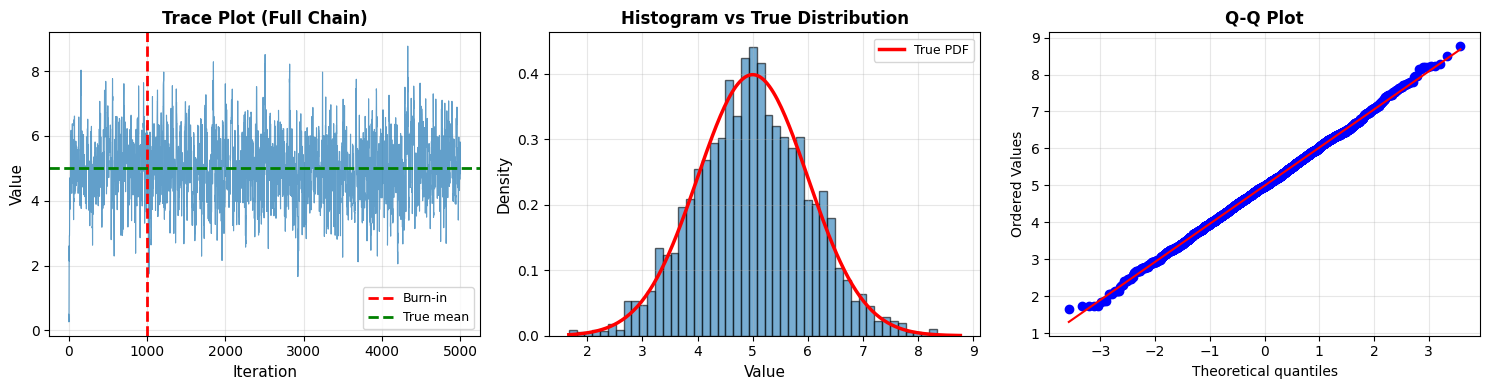

In [ ]:
# Create a figure with three subplots to visualize our results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# First plot: Trace plot showing the evolution of the chain over time
axes[0].plot(chain, alpha=0.7, linewidth=0.8)
# Mark where the burn-in period ends
axes[0].axvline(burn_in, color='red', linestyle='--', linewidth=2, label='Burn-in')
# Show the true mean for reference
axes[0].axhline(theoretical_mean, color='green', linestyle='--', linewidth=2, label='True mean')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Value', fontsize=11)
axes[0].set_title('Trace Plot (Full Chain)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Second plot: Histogram comparing our samples to the true distribution
axes[1].hist(chain_burned, bins=50, density=True, alpha=0.6, edgecolor='black')
# Generate points for the true probability density function
x_range = np.linspace(chain_burned.min(), chain_burned.max(), 200)
# Calculate the true PDF at these points
true_pdf = stats.norm.pdf(x_range, theoretical_mean, theoretical_std)
# Overlay the theoretical distribution in red
axes[1].plot(x_range, true_pdf, 'r-', linewidth=2.5, label='True PDF')
axes[1].set_xlabel('Value', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Histogram vs True Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Third plot: Q-Q plot to check if our samples follow a normal distribution
stats.probplot(chain_burned, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

#Question 2: MH with Asymmetric Proposal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# (a) Target: Exponential distribution with rate lambda = 0.5
def target_f(x):
    # Target f(x) = 0.5 * exp(-0.5 * x) for x > 0
    if x <= 0:
        return 0.0
    probability = 0.5 * np.exp(-0.5 * x)
    return probability

# Proposal density q(x_prime | x_t)
# Question defines x' = x_t + Y, where Y ~ Exponential(1)
def proposal_q(x_dest, x_orig):
    y = x_dest - x_orig
    # Asymmetric: because Y is from Exp(1), y must be positive
    if y < 0:
        return 0.0
    # PDF of Exponential(1) is exp(-y)
    return np.exp(-y)

# Metropolis-Hastings Parameters
n_iterations = 5000
samples = [1.0] # Starting from x0 = 1
x_t = 1.0

for _ in range(n_iterations - 1):
    # Propose x' = x_t + Y
    y_sample = np.random.exponential(1.0)
    x_prop = x_t + y_sample

    # Calculate alpha = min(1, (f(x') * q(x_t | x')) / (f(x_t) * q(x' | x_t)))
    # Note: q(x_t | x_prop) is the probability of moving backward
    f_prop = target_f(x_prop)
    f_curr = target_f(x_t)
    q_back = proposal_q(x_t, x_prop) # This will be 0 per the definition
    q_fwd  = proposal_q(x_prop, x_t)

    # Standard MH acceptance ratio logic
    numerator = f_prop * q_back
    denominator = f_curr * q_fwd

    if denominator > 0:
        alpha = min(1, numerator / denominator)
    else:
        alpha = 0

    # Accept/Reject step
    if np.random.rand() < alpha:
        x_t = x_prop

    samples.append(x_t)

print(f"Empirical Mean: {np.mean(samples):.4f}")

Empirical Mean: 1.0000


#Question 3: Coin Bias inference

In [ ]:
num_flips = 100
num_heads = 60
num_tails = num_flips - num_heads

def likelihood_coin(theta, heads, tails):
  if theta < 0 or theta > 1:
    return 0.0
  return (theta**heads) * ((1-theta) ** tails)

def prior_coin(theta):
    if theta < 0 or theta > 1:
        return 0.0
    return 1.0

def posterior_coin(theta, heads, tails):
    return prior_coin(theta) * likelihood_coin(theta, heads, tails)

print(f'Data: {num_heads} heads out of {num_flips} flips')
print(f'Observed success rate: {num_heads/num_flips:.2f}')
print(f'Posterior at theta=0.6: {posterior_coin(0.6, num_heads, num_tails):.6e}')



Data: 60 heads out of 100 flips
Observed success rate: 0.60
Posterior at theta=0.6: 5.908465e-30


In [ ]:
def metropolis_coin_example4(num_heads, num_tails, num_iterations=10000):
    chain = []
    current_theta = 0.6
    proposal_std = 0.1
    acceptances = []

    for iteration in range(num_iterations):
        proposed_theta = current_theta + np.random.normal(0, proposal_std)

        if proposed_theta < 0 or proposed_theta > 1:
            chain.append(current_theta)
            acceptances.append(False)
            continue

        posterior_proposed = posterior_coin(proposed_theta, num_heads, num_tails)
        posterior_current = posterior_coin(current_theta, num_heads, num_tails)

        acceptance_probability = min(1.0, posterior_proposed / posterior_current)

        if np.random.uniform(0, 1) < acceptance_probability:
            current_theta = proposed_theta
            accepted = True
        else:
            accepted = False

        chain.append(current_theta)
        acceptances.append(accepted)

    return np.array(chain), np.mean(acceptances)

print('Metropolis for coin bias defined!')

Metropolis for coin bias defined!


In [ ]:
num_iterations_ex4 = 10000
theta_chain, acceptance_rate_ex4 = metropolis_coin_example4(num_heads, num_tails, num_iterations_ex4)

burn_in_ex4 = int(0.2 * num_iterations_ex4)
theta_burned = theta_chain[burn_in_ex4:]

posterior_mean = np.mean(theta_burned)
posterior_std = np.std(theta_burned)
posterior_lower = np.percentile(theta_burned, 2.5)
posterior_upper = np.percentile(theta_burned, 97.5)

print('='*60)
print('EXAMPLE 4 RESULTS: COIN BIAS INFERENCE')
print('='*60)
print(f'\nData: {num_heads} heads, {num_tails} tails out of {num_flips} flips')
print(f'Observed proportion: {num_heads/num_flips:.4f}')
print(f'\nPosterior mean: {posterior_mean:.4f}')
print(f'Posterior std dev: {posterior_std:.4f}')
print(f'95% Credible interval: [{posterior_lower:.4f}, {posterior_upper:.4f}]')
print(f'\nInterpretation: We are 95 percent confident the true bias is between {posterior_lower:.3f} and {posterior_upper:.3f}')
print('='*60)

EXAMPLE 4 RESULTS: COIN BIAS INFERENCE

Data: 60 heads, 40 tails out of 100 flips
Observed proportion: 0.6000

Posterior mean: 0.6000
Posterior std dev: 0.0483
95% Credible interval: [0.5025, 0.6927]

Interpretation: We are 95 percent confident the true bias is between 0.502 and 0.693


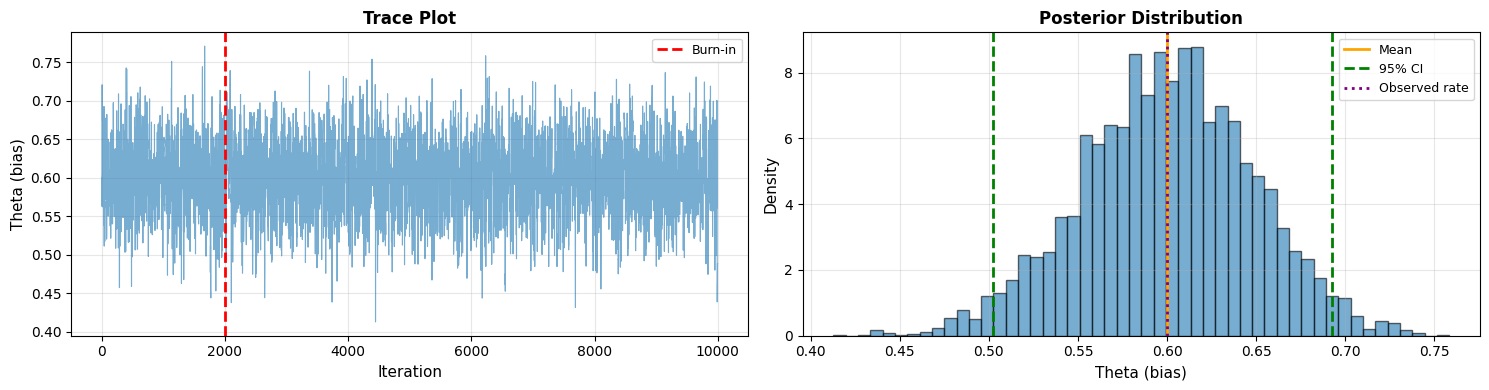

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(theta_chain, alpha=0.6, linewidth=0.8)
axes[0].axvline(burn_in_ex4, color='red', linestyle='--', linewidth=2, label='Burn-in')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Theta (bias)', fontsize=11)
axes[0].set_title('Trace Plot', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].hist(theta_burned, bins=50, density=True, alpha=0.6, edgecolor='black')
axes[1].axvline(posterior_mean, color='orange', linestyle='-', linewidth=2, label='Mean')
axes[1].axvline(posterior_lower, color='green', linestyle='--', linewidth=2, label='95% CI')
axes[1].axvline(posterior_upper, color='green', linestyle='--', linewidth=2)
axes[1].axvline(num_heads/num_flips, color='purple', linestyle=':', linewidth=2, label='Observed rate')
axes[1].set_xlabel('Theta (bias)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Posterior Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()